# 선문대학교 컴퓨터공학부
# 2022243101 최완우

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 타이타닉 CSV 파일 불러오기
titanic = pd.read_csv('3.1.titanic.csv')


In [2]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
titanic = pd.read_csv('3.1.titanic.csv')

# 객실 등급에 따른 생존자와 사망자의 평균 계산
pclass_survived_mean = titanic.groupby('Pclass')['Survived'].mean().reset_index()
pclass_survived_mean


,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


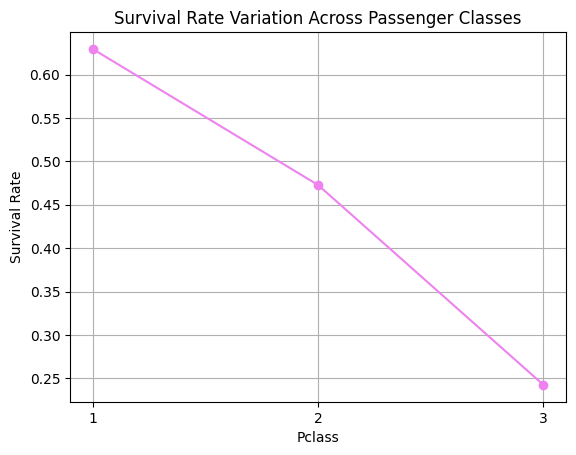

In [5]:
# 선 그래프 그리기
plt.plot(pclass_survived_mean['Pclass'], pclass_survived_mean['Survived'], marker='o', linestyle='-', color='violet')
plt.title('Survival Rate Variation Across Passenger Classes')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
plt.xticks([1, 2, 3])
plt.grid(True)
plt.show()

In [6]:
# 승선 항구에 따른 생존자의 수 계산
survived_counts = titanic[titanic['Survived'] == 1]['Embarked'].value_counts()
survived_counts


Embarked
S    217
C     93
Q     30
Name: count, dtype: int64

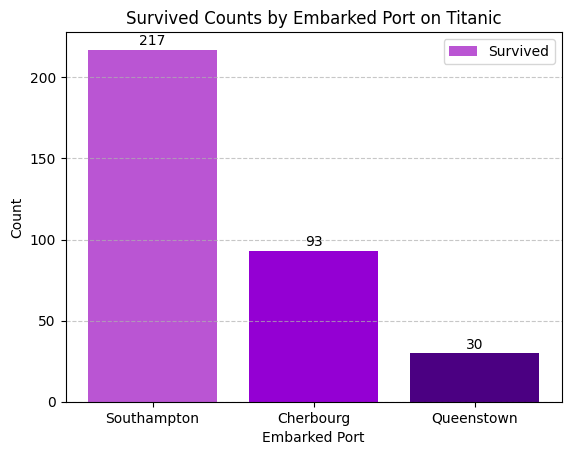

In [7]:
# 막대 그래프 그리기
plt.bar(survived_counts.index, survived_counts, color = ['mediumorchid', 'darkviolet', 'indigo'])
plt.title('Survived Counts by Embarked Port on Titanic')
plt.xlabel('Embarked Port')
plt.ylabel('Count')
plt.xticks(survived_counts.index, ['Southampton', 'Cherbourg', 'Queenstown'])
plt.legend(['Survived'], loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 생존자 수 표시
for i, value in enumerate(survived_counts):
  plt.text(i, value + 1, str(value), ha='center', va='bottom')
plt.show()


In [8]:
# 성별에 따른 생존자의 수 계산
survived_counts = titanic[titanic['Survived'] == 1]['Sex'].value_counts()
survived_counts


Sex
female    233
male      109
Name: count, dtype: int64

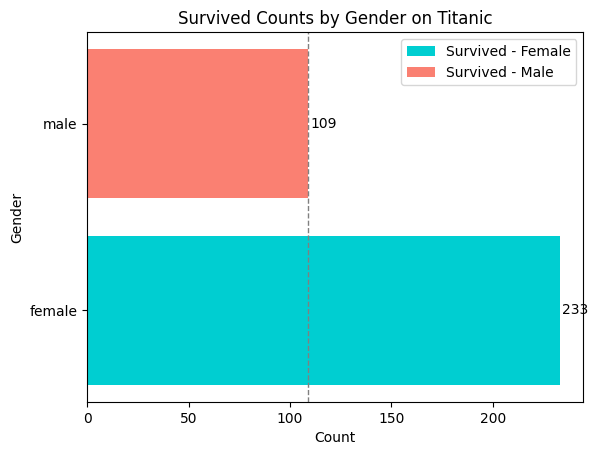

In [9]:
bars = plt.barh(survived_counts.index, survived_counts, color=['darkturquoise', 'salmon'])
plt.title('Survived Counts by Gender on Titanic')
plt.xlabel('Count')
plt.ylabel('Gender')
plt.legend(bars, ['Survived - Female', 'Survived - Male'], loc='upper right')

# 차이 강조를 위해 수평선 추가
plt.axvline(x=survived_counts['male'], color='gray', linestyle='--', linewidth=1)

# 생존자 수 표시
for i, value in enumerate(survived_counts):
  plt.text(value + 1, i, str(value), ha='left', va='center')
plt.show()


In [10]:
print(titanic.info(), '\n')

# 결측치 처리
titanic = titanic.dropna(subset=['Age', 'Fare', 'Survived'])
print(titanic.info())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None 

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int

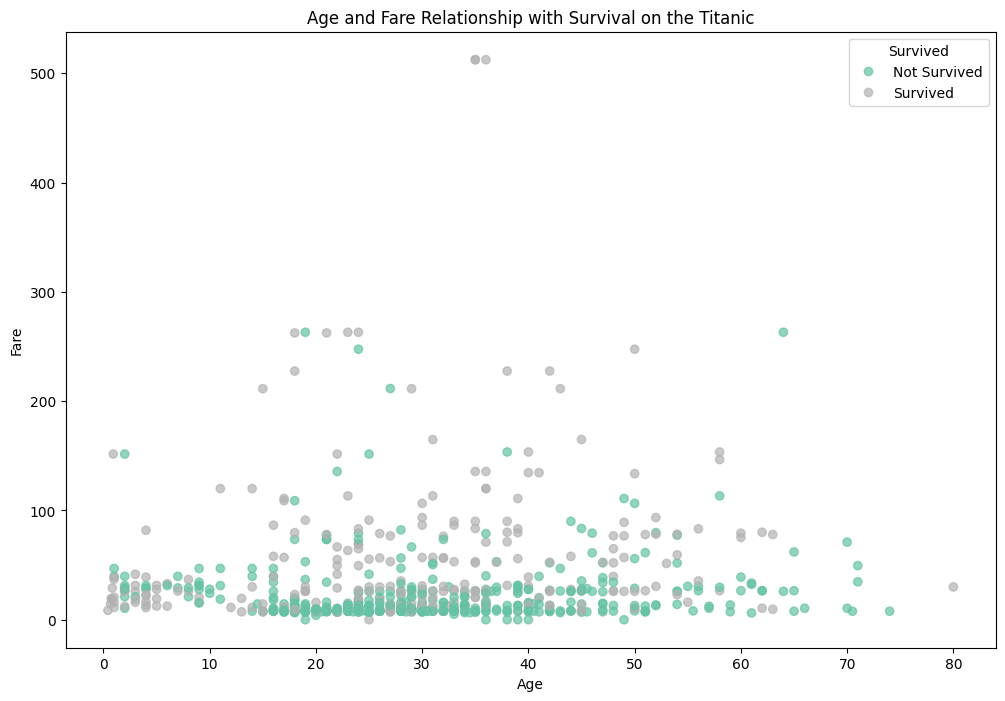

In [11]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(x='Age', y='Fare', data=titanic, c=titanic['Survived'], cmap='Set2', alpha=0.7)

plt.title('Age and Fare Relationship with Survival on the Titanic')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(handles=scatter.legend_elements()[0], title='Survived', labels=['Not Survived', 'Survived'], loc='upper right')
plt.show()

In [12]:
# 사망자와 생존자의 수 계산
survived_counts = titanic['Survived'].value_counts()
survived_counts


Survived
0    424
1    290
Name: count, dtype: int64

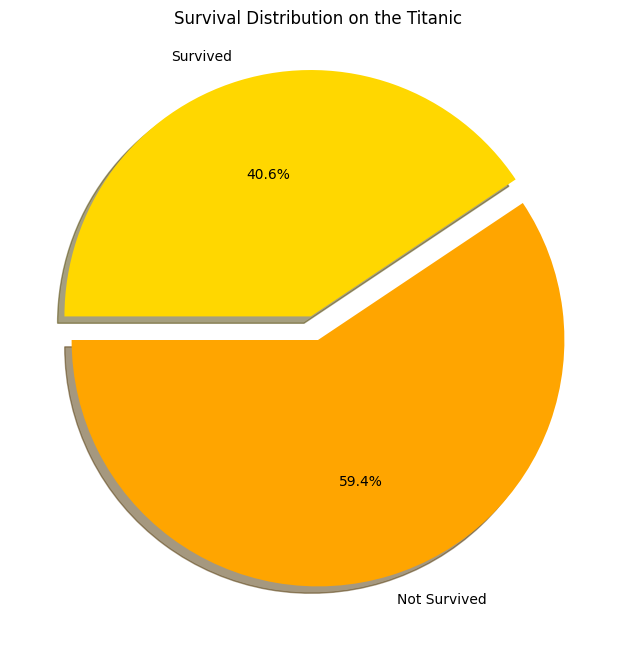

In [13]:
plt.figure(figsize=(8, 8))
plt.pie(survived_counts, labels=['Not Survived', 'Survived'], colors=['orange', 'gold'],
        	   autopct='%0.1f%%', startangle=180, shadow=True, explode=(0, 0.1))

plt.title('Survival Distribution on the Titanic')
plt.show()


In [14]:
titanic = pd.read_csv('3.1.titanic.csv')
print(titanic.info(), '\n')

titanic = titanic.dropna(subset=['Age'])
print(titanic.info())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None 

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int

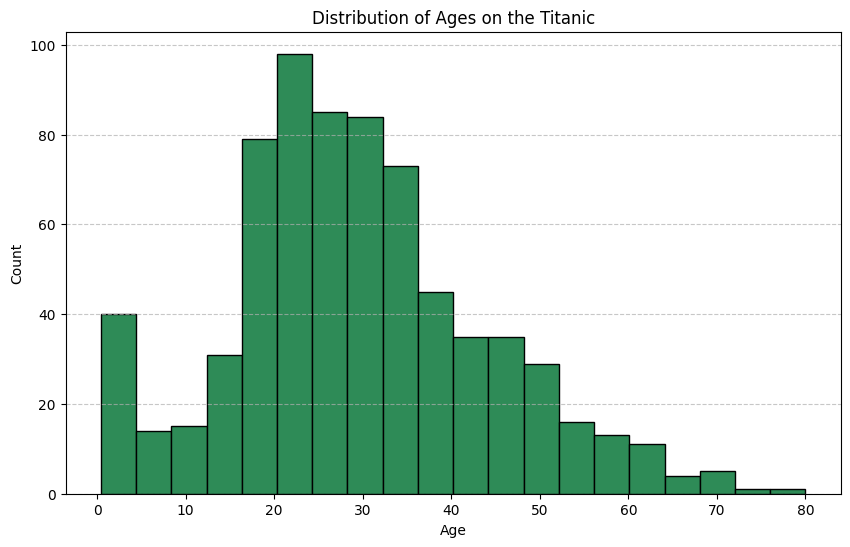

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(titanic['Age'], bins=20, color='seagreen', edgecolor='black')

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distribution of Ages on the Titanic')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [16]:
titanic = pd.read_csv('3.1.titanic.csv')
titanic = titanic.dropna(subset=['Age', 'Fare'])		# 결측치 처리

# 상관 행렬 계산
correlation_matrix = titanic.drop('PassengerId', axis=1).corr(numeric_only=True)
correlation_matrix


,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.359653,-0.077221,-0.017358,0.093317,0.268189
Pclass,-0.359653,1.000000,-0.369226,0.067247,0.025683,-0.554182
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.017358,0.067247,-0.308247,1.000000,0.383820,0.138329
Parch,0.093317,0.025683,-0.189119,0.383820,1.000000,0.205119
Fare,0.268189,-0.554182,0.096067,0.138329,0.205119,1.000000


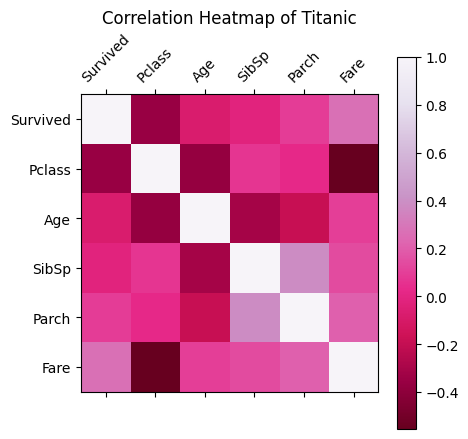

In [17]:
plt.matshow(correlation_matrix, cmap='PuRd_r')
plt.colorbar()			# 오른쪽에 색상 참고를 위한 컬러바 추가

# x축과 y축의 눈금 설정
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Heatmap of Titanic')
plt.show()


In [18]:
titanic = pd.read_csv('3.1.titanic.csv')
titanic = titanic.dropna(subset=['Age', 'Fare'])		# 결측치 처리

# 나이대별 생존자와 사망자 수 계산하기 위해 범주형 변수로 변환
age_groups = pd.cut(titanic['Age'], bins=range(0, 81, 5))

# Age, Survived 기준으로 그룹화
survived_counts = titanic.groupby([age_groups, 'Survived'], observed=False).size().unstack().fillna(0)
survived_counts


Survived,0,1
Age,,
"(0, 5]",13,31
"(5, 10]",13,7
"(10, 15]",8,11
"(15, 20]",63,33
"(20, 25]",80,42
"(25, 30]",66,42
"(30, 35]",47,41
"(35, 40]",39,28
"(40, 45]",30,17


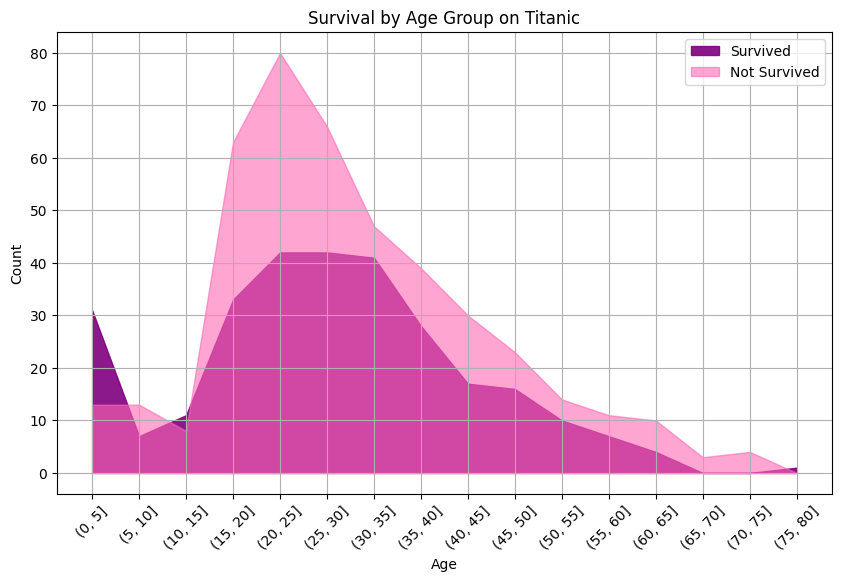

In [19]:
plt.figure(figsize=(10, 6))	 # 영역 채우기 그래프 그리기

# 나이대별 생존자
plt.fill_between(survived_counts.index.astype(str), survived_counts[1],
                 color='purple', alpha=0.9, label='Survived')

# 나이대별 사망자
plt.fill_between(survived_counts.index.astype(str), survived_counts[0],
                 color='hotpink', alpha=0.6, label='Not Survived')

plt.title('Survival by Age Group on Titanic')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


In [20]:
titanic = pd.read_csv('3.1.titanic.csv')
titanic = titanic.dropna(subset = ['Age'])

C:\Users\최완우\AppData\Local\Temp\ipykernel_13712\3617821946.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([titanic[titanic['Pclass'] == 1]['Age'],


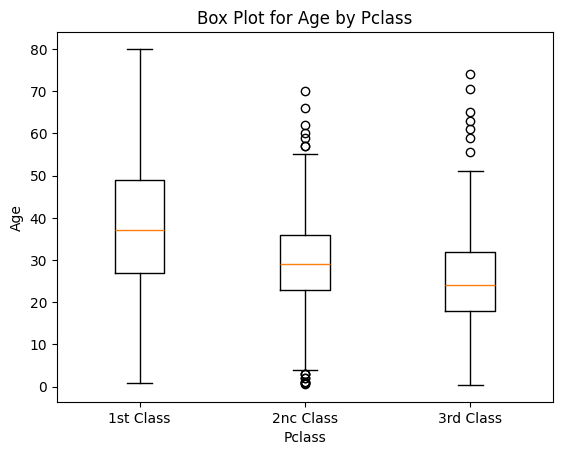

In [22]:
plt.boxplot([titanic[titanic['Pclass'] == 1]['Age'],
             titanic[titanic['Pclass'] == 2]['Age'],
             titanic[titanic['Pclass'] == 3]['Age']],
            labels = ['1st Class', '2nc Class', '3rd Class'])

plt.title('Box Plot for Age by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Age')
plt.show()

In [23]:
titanic = pd.read_csv('3.1.titanic.csv')
titanic = titanic.dropna(subset = ['Age'])

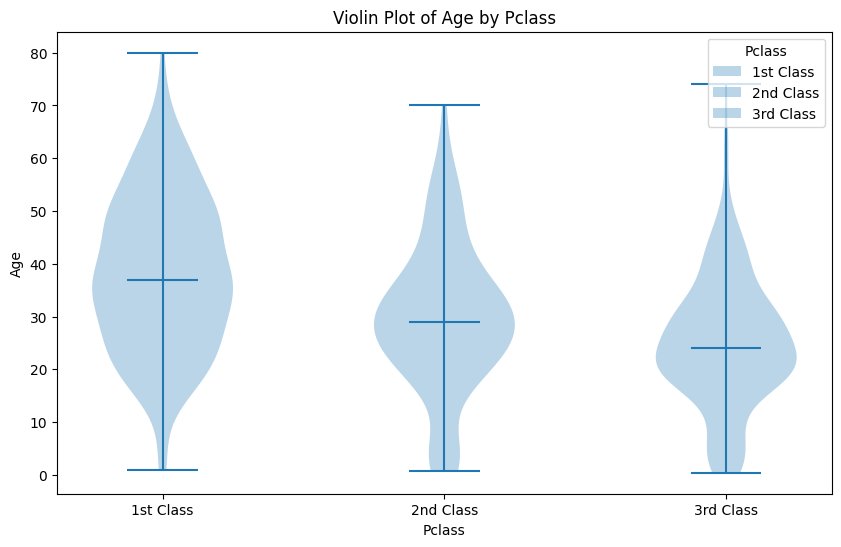

In [25]:
plt.figure(figsize = (10, 6))

violin_plot = plt.violinplot([titanic[titanic['Pclass'] == 1]['Age'],
                              titanic[titanic['Pclass'] == 2]['Age'],
                              titanic[titanic['Pclass'] == 3]['Age']],
                             showmeans = False, showmedians = True)

plt.title('Violin Plot of Age by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Age')

plt.xticks([1, 2, 3], ['1st Class', '2nd Class', '3rd Class'])
plt.legend(violin_plot['bodies'], ['1st Class', '2nd Class', '3rd Class'],
           title = 'Pclass', loc = 'upper right')
plt.show()

In [27]:
titanic = pd.read_csv('3.1.titanic.csv')

fare_means = titanic.groupby('Parch')['Fare'].mean()
print(fare_means, '\n')

fare_std = titanic.groupby('Parch')['Fare'].std()
print(fare_std)

Parch
0    25.586774
1    46.778180
2    64.337604
3    25.951660
4    84.968750
5    32.550000
6    46.900000
Name: Fare, dtype: float64 

Parch
0     41.878786
1     63.709430
2     65.993088
3      7.862611
4    118.731099
5      4.101134
6           NaN
Name: Fare, dtype: float64


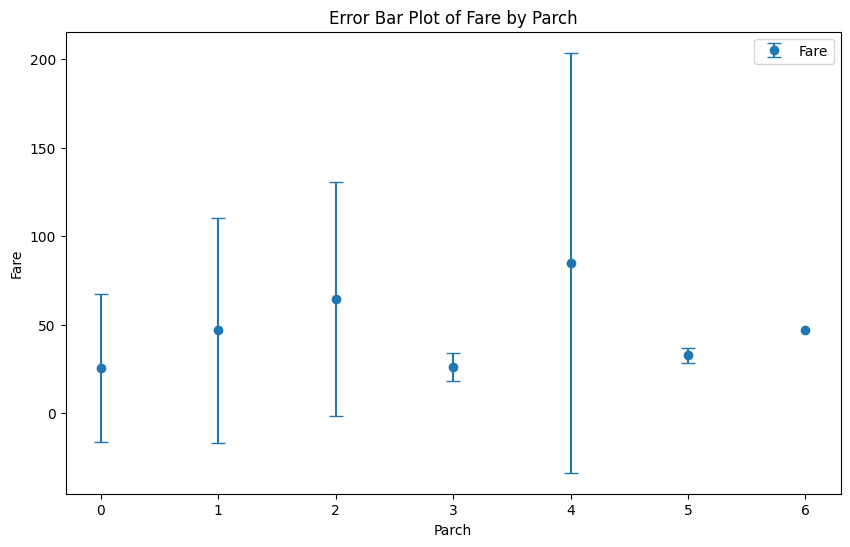

In [28]:
plt.figure(figsize = (10, 6))

plt.errorbar(fare_means.index, fare_means, yerr = fare_std, fmt = 'o',
             capsize = 5, capthick = 1, label = 'Fare')

plt.title('Error Bar Plot of Fare by Parch')
plt.xlabel('Parch')
plt.ylabel('Fare')
plt.xticks(fare_means.index)
plt.legend()
plt.show()